In [1]:
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Dataset path
path = "/content"
print("Dataset path:", path)

# Load dataset
csv_file = "StudentsPerformance.csv"
df = pd.read_csv(csv_file)

print("\nFirst 5 rows:")
display(df.head())

Dataset path: /content

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical description:")
display(df.describe(include="all").T)


Last 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Shape:
(1000, 8)

Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types:
gender                         object
race/ethnicity               

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race/ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental level of education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test preparation course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [3]:
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


Duplicate rows:
0


In [4]:
print("\nGender Distribution:")
display(df["gender"].value_counts())

print("\nRace/Ethnicity Distribution:")
display(df["race/ethnicity"].value_counts())

print("\nParental Level of Education:")
display(df["parental level of education"].value_counts())

print("\nTest Preparation Course:")
display(df["test preparation course"].value_counts())


Gender Distribution:


gender
female    518
male      482
Name: count, dtype: int64


Race/Ethnicity Distribution:


race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


Parental Level of Education:


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


Test Preparation Course:


test preparation course
none         642
completed    358
Name: count, dtype: int64

In [5]:
print("\nCorrelation:")
display(df.corr(numeric_only=True))


Correlation:


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [6]:
# Export CSV
df.to_csv("students_performance.csv", index=False)

# Export Excel
df.to_excel("students_performance.xlsx", index=False)

# SQLite database
conn = sqlite3.connect("students_performance.db")

df.to_sql(
    "student_performance",
    conn,
    if_exists="replace",
    index=False
)

conn.close()

print("\nCSV, Excel and SQLite database files created successfully.")


CSV, Excel and SQLite database files created successfully.


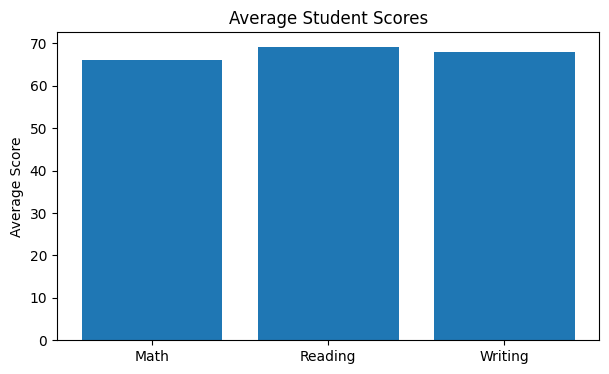

In [7]:
# Average student scores
means = df[["math score", "reading score", "writing score"]].mean()

plt.figure(figsize=(7, 4))
plt.bar(["Math", "Reading", "Writing"], means.values)
plt.title("Average Student Scores")
plt.ylabel("Average Score")
plt.show()

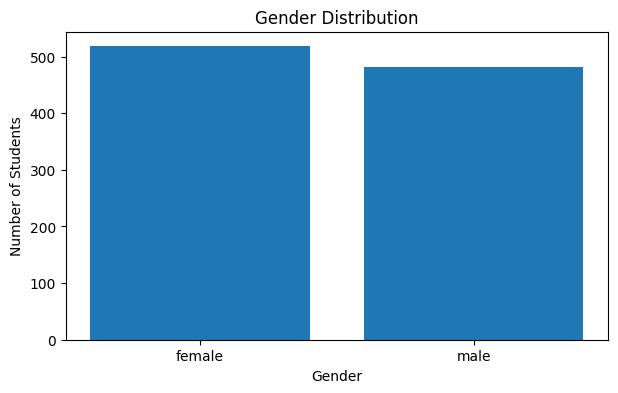

In [8]:
# Gender distribution
gender = df["gender"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(gender.index, gender.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

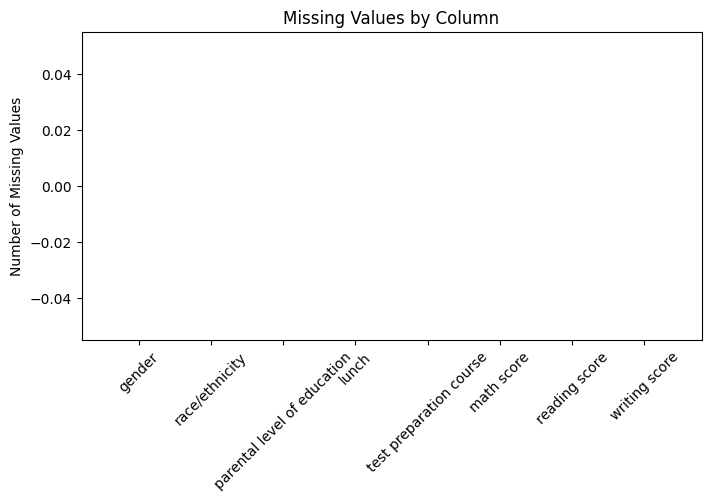

In [9]:
# Missing values visualization
missing = df.isnull().sum()

plt.figure(figsize=(8, 4))
plt.bar(missing.index, missing.values)
plt.title("Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()